In [2]:
import pandas as pd       # for reading and handling data
import matplotlib.pyplot as plt  # for plotting

import warnings
warnings.filterwarnings('ignore')


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Shahab Computer KTA\Downloads\Tesla.csv")
print(df.head())


        Date       Open   High        Low      Close    Volume  Adj Close
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300  23.889999
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800  21.959999
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800  19.200001
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900  16.110001


In [4]:
df.shape

(1692, 7)

In [5]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


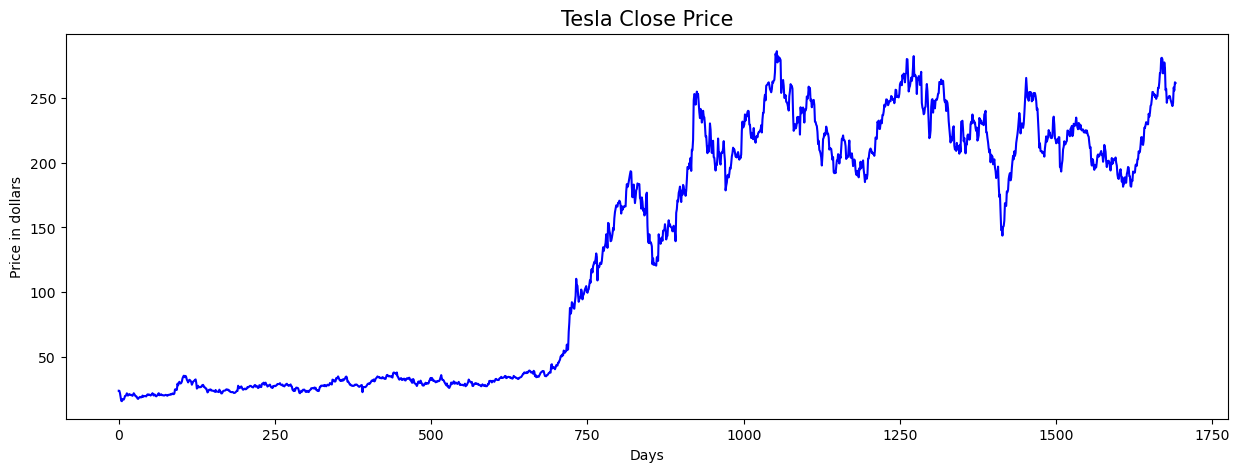

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Close'], color='blue')
plt.title('Tesla Close Price', fontsize=15)
plt.ylabel('Price in dollars')
plt.xlabel('Days')
plt.show()

In [8]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [9]:
# Count rows where Close price is equal to Adjusted Close price
matching_rows = df[df['Close'] == df['Adj Close']].shape
print(matching_rows)

(1692, 7)


In [10]:
# Drop the 'Adj Close' column
df = df.drop('Adj Close', axis=1)
print(df.head())

        Date       Open   High        Low      Close    Volume
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900


In [11]:
# Check for missing values in each column
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


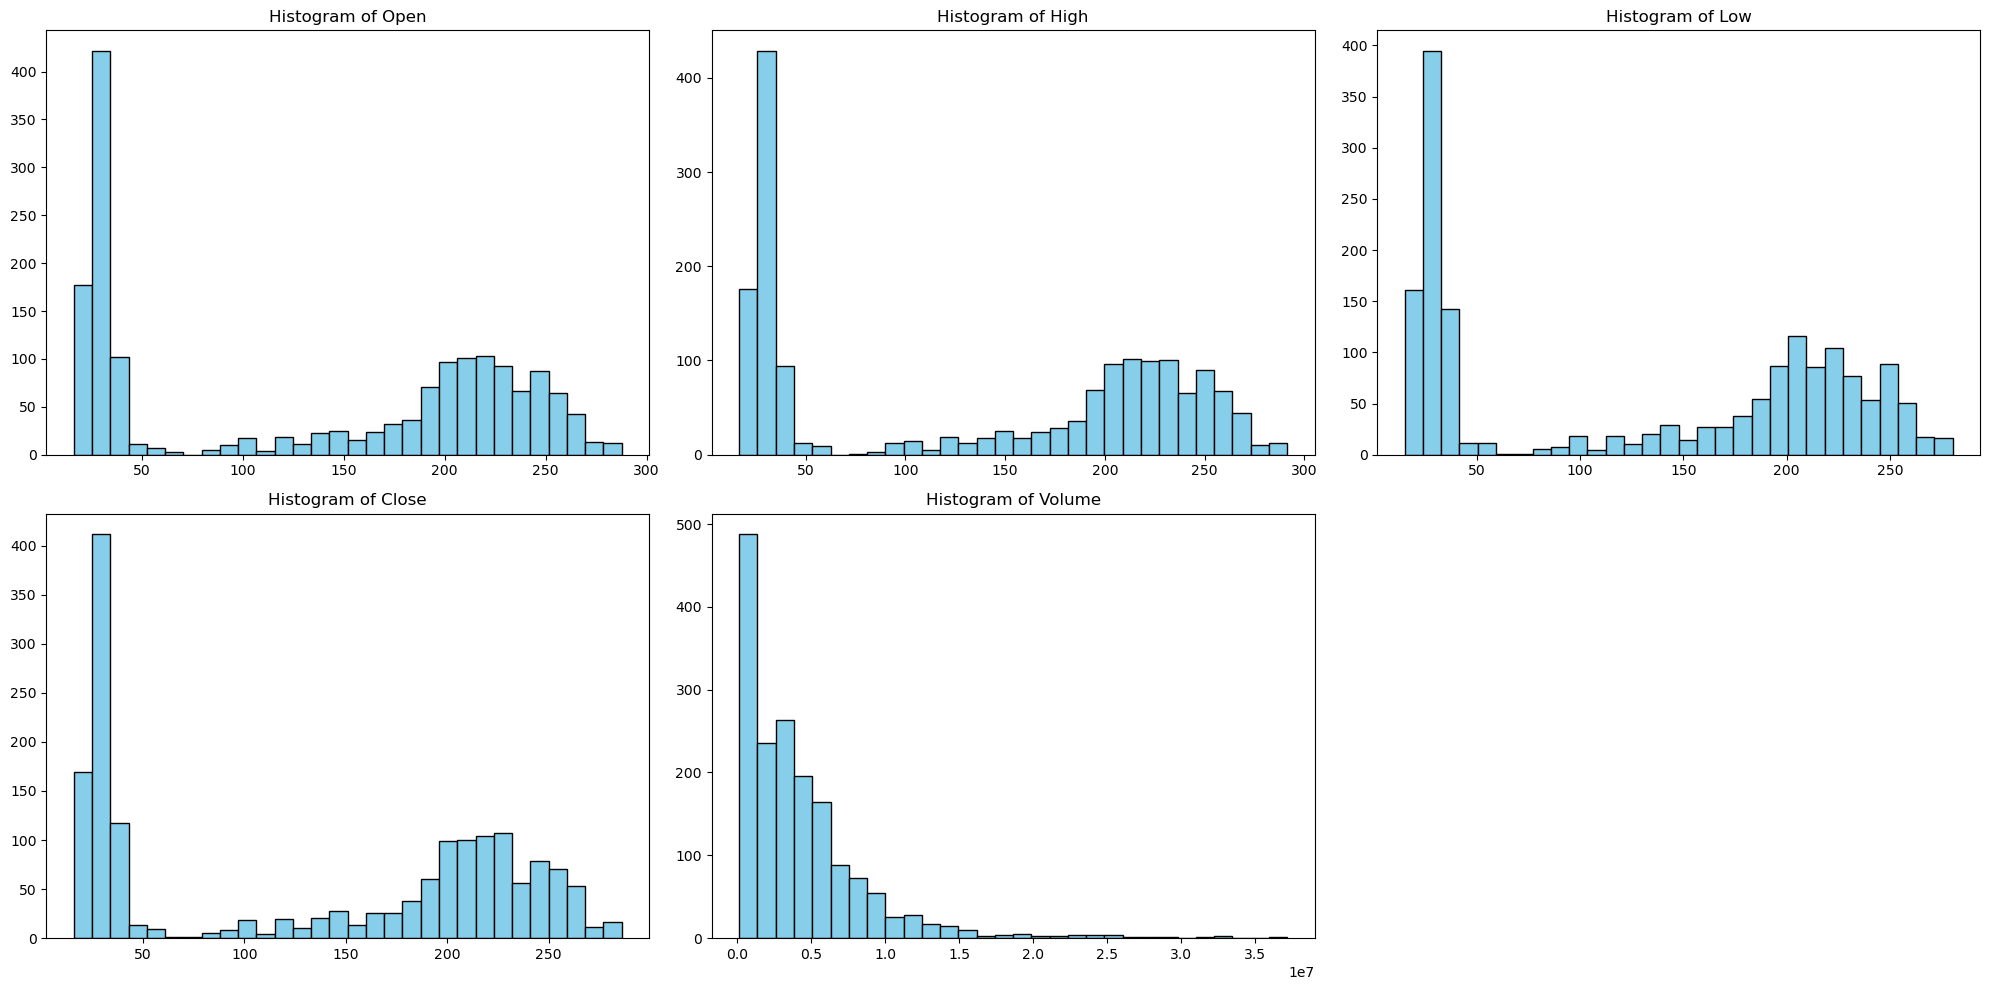

In [12]:
import matplotlib.pyplot as plt

features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(20,10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()


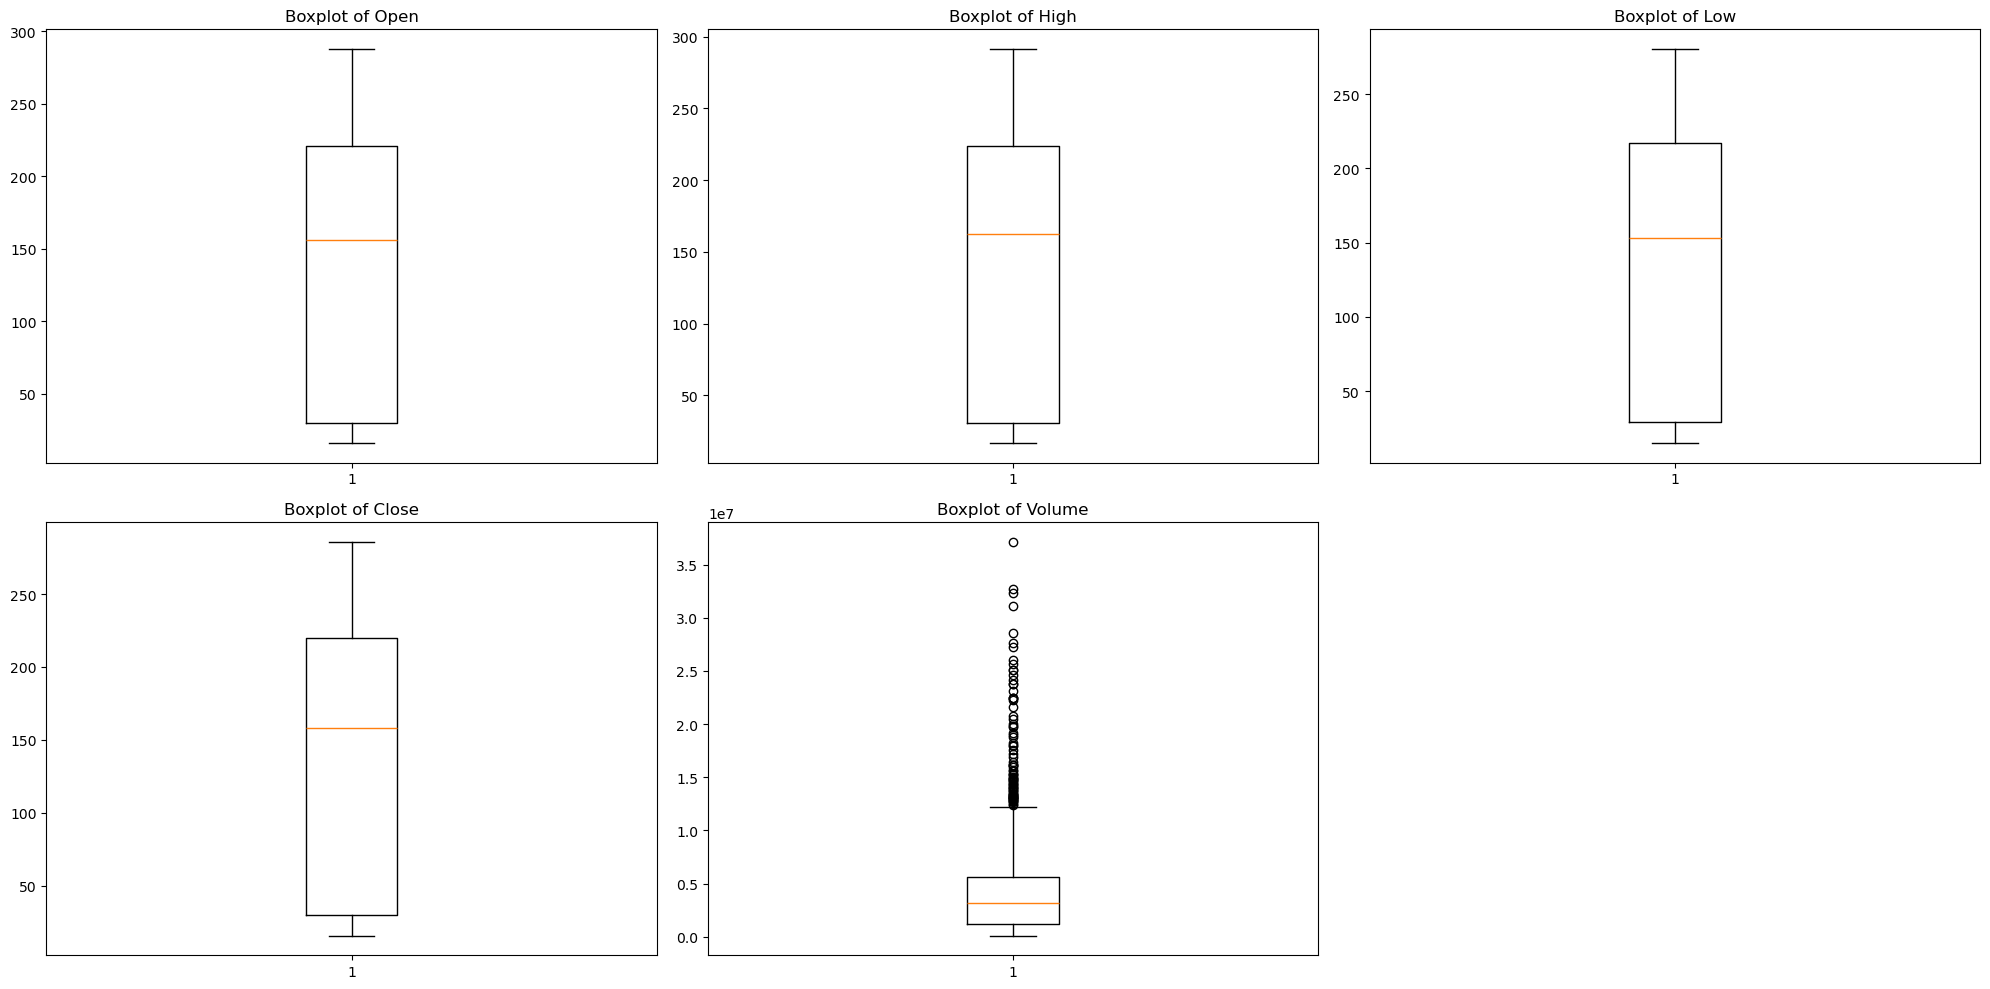

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [14]:
# Split the 'Date' column into day, month, year
splitted = df['Date'].str.split('/', expand=True)

df['month'] = splitted[0].astype(int)
df['day'] = splitted[1].astype(int)
df['year'] = splitted[2].astype(int)

print(df.head())


        Date       Open   High        Low      Close    Volume  month  day  \
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300      6   29   
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100      6   30   
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800      7    1   
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800      7    2   
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900      7    6   

   year  
0  2010  
1  2010  
2  2010  
3  2010  
4  2010  


In [15]:
# Create 'is_quarter_end' column: 1 if month is multiple of 3, else 0
df['is_quarter_end'] = df['month'].apply(lambda x: 1 if x % 3 == 0 else 0)
print(df.head())

        Date       Open   High        Low      Close    Volume  month  day  \
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300      6   29   
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100      6   30   
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800      7    1   
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800      7    2   
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900      7    6   

   year  is_quarter_end  
0  2010               1  
1  2010               1  
2  2010               0  
3  2010               0  
4  2010               0  


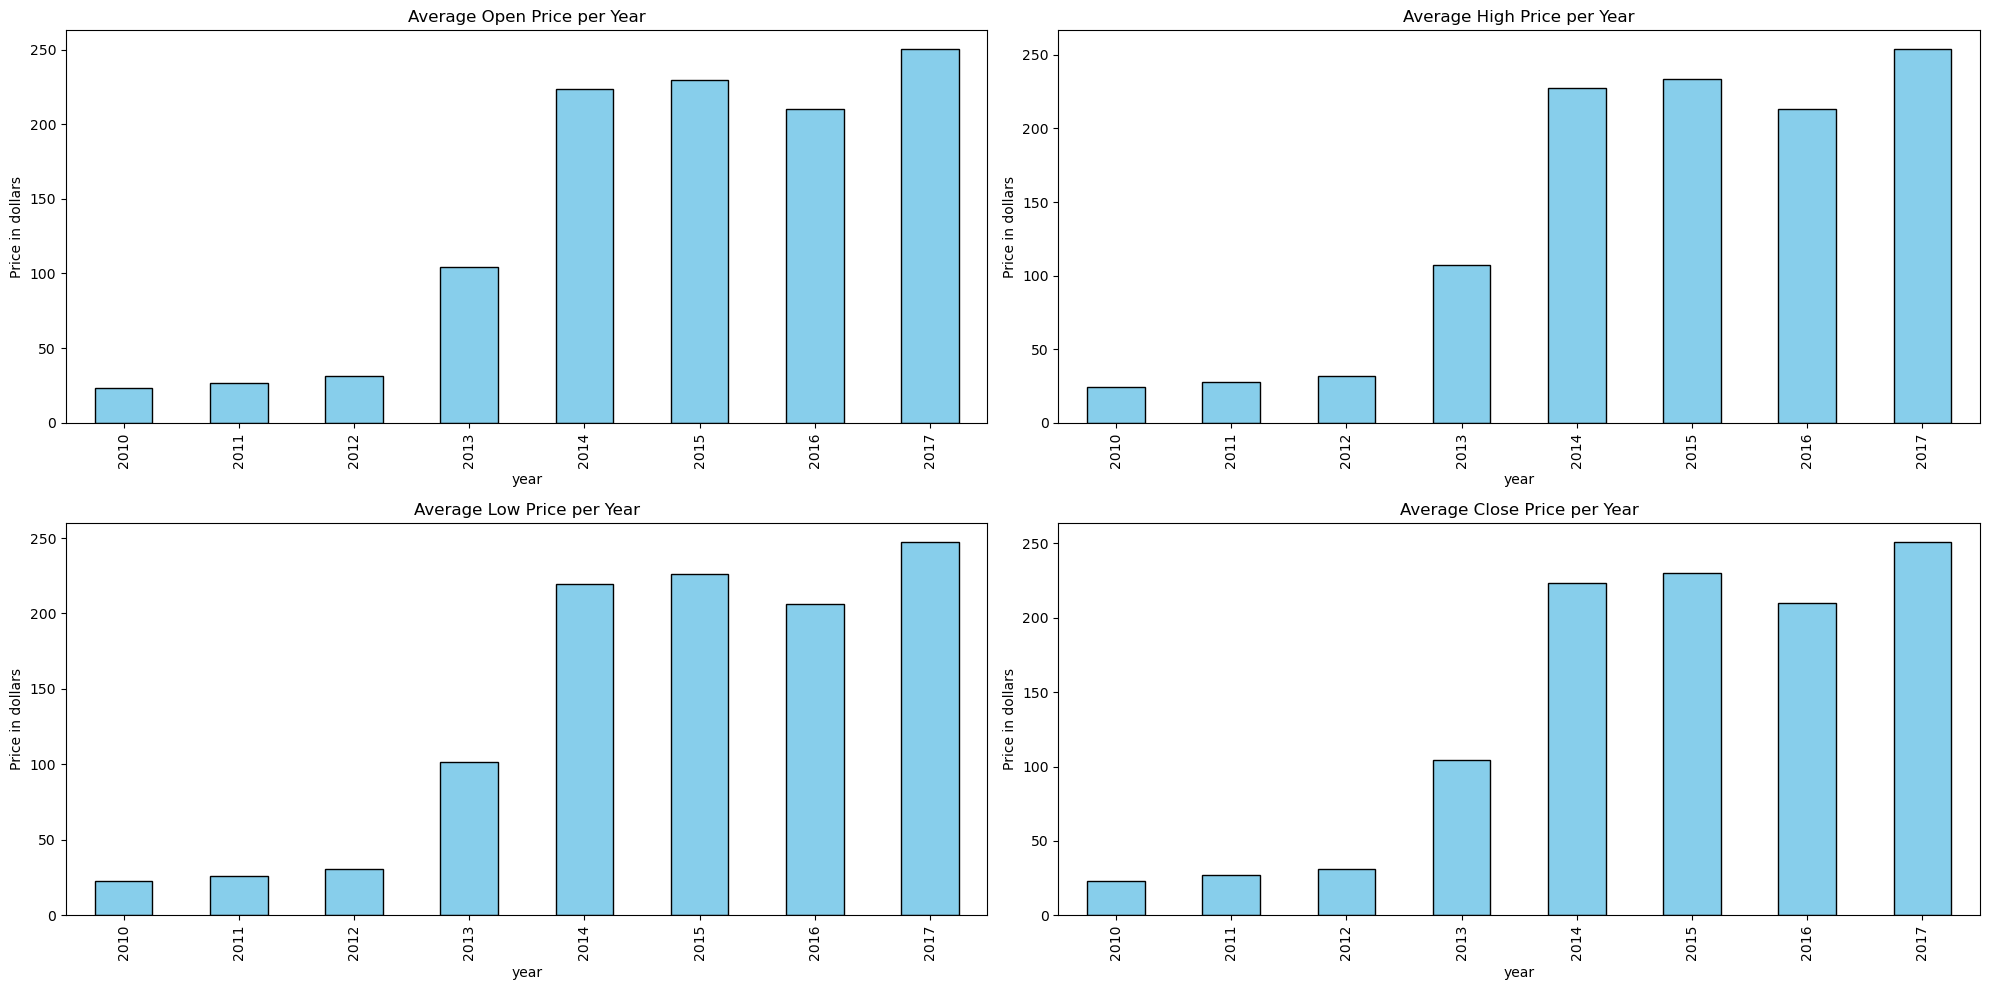

In [16]:
import matplotlib.pyplot as plt

# Drop 'Date' column and group by 'year', then take the mean
data_grouped = df.drop('Date', axis=1).groupby('year').mean()

plt.figure(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i+1)
    data_grouped[col].plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Average {col} Price per Year')
    plt.ylabel('Price in dollars')

plt.tight_layout()
plt.show()


In [17]:
# Drop 'Date' column, group by 'is_quarter_end', and calculate mean
quarter_end_grouped = df.drop('Date', axis=1).groupby('is_quarter_end').mean()
print(quarter_end_grouped)

                      Open        High         Low       Close        Volume  \
is_quarter_end                                                                 
0               130.813739  133.182620  128.257229  130.797709  4.461581e+06   
1               135.679982  137.927032  133.455777  135.673269  3.891084e+06   

                   month        day         year  
is_quarter_end                                    
0               6.141208  15.686501  2013.353464  
1               7.584806  15.657244  2013.314488  


In [20]:
# Create difference columns
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']

# Create 'target' column: 1 if next day's Close is higher, else 0
df['target'] = [1 if df['Close'].iloc[i+1] > df['Close'].iloc[i] else 0 for i in range(len(df)-1)] + [0]

print(df.head())


        Date       Open   High        Low      Close    Volume  month  day  \
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300      6   29   
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100      6   30   
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800      7    1   
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800      7    2   
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900      7    6   

   year  is_quarter_end  open-close  low-high  target  
0  2010               1   -4.889999 -7.459999       0  
1  2010               1    1.960001 -7.120001       0  
2  2010               0    3.040001 -5.650000       0  
3  2010               0    3.799999 -4.390001       0  
4  2010               0    3.889999 -4.170000       0  


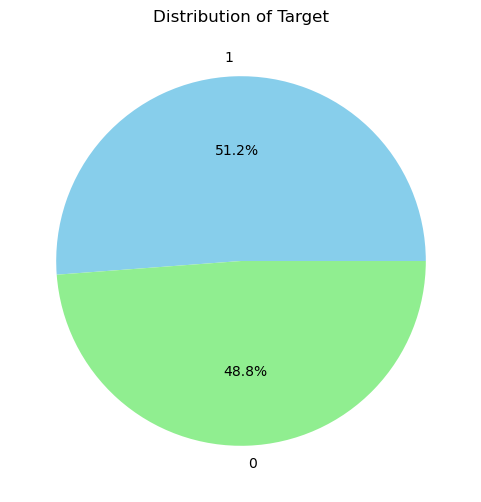

In [21]:
import matplotlib.pyplot as plt

# Plot pie chart of target value counts
target_counts = df['target'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Target')
plt.show()


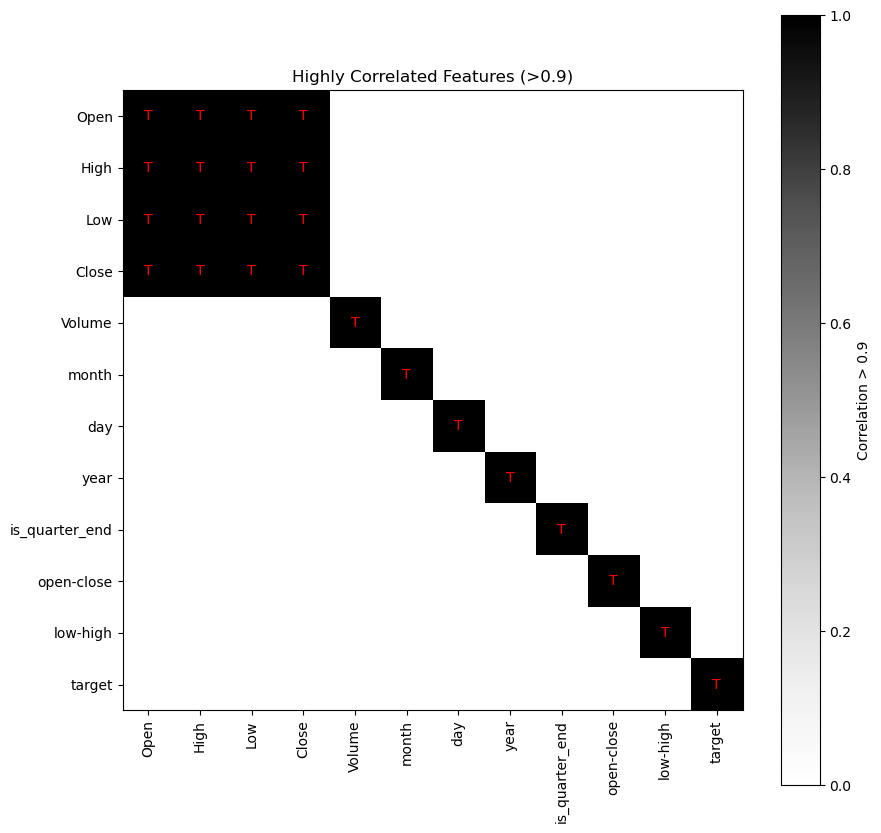

In [22]:
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.drop('Date', axis=1).corr()

# Keep only highly correlated features (correlation > 0.9)
high_corr = corr_matrix > 0.9

plt.figure(figsize=(10,10))
plt.imshow(high_corr, cmap='Greys', interpolation='none')
plt.colorbar(label='Correlation > 0.9')

# Add feature labels
plt.xticks(range(len(high_corr.columns)), high_corr.columns, rotation=90)
plt.yticks(range(len(high_corr.columns)), high_corr.columns)

# Annotate True values
for i in range(len(high_corr.columns)):
    for j in range(len(high_corr.columns)):
        if high_corr.iloc[i,j]:
            plt.text(j, i, 'T', ha='center', va='center', color='red')

plt.title('Highly Correlated Features (>0.9)')
plt.show()


In [23]:
# Select features and target
features = df[['open-close', 'low-high', 'is_quarter_end']].copy()
target = df['target'].copy()

# Manual StandardScaler: (x - mean) / std
features_scaled = (features - features.mean()) / features.std()

# Convert to lists for easier indexing
X = features_scaled.values.tolist()
Y = target.tolist()

# Manual train-test split (90% train, 10% test)
split_index = int(len(X) * 0.9)
X_train = X[:split_index]
X_valid = X[split_index:]
Y_train = Y[:split_index]
Y_valid = Y[split_index:]

print(len(X_train), len(X_valid))


1522 170


In [24]:
# Simple rule-based model: predict 1 if 'open-close' > 0, else 0
def simple_model(X):
    return [1 if x[0] > 0 else 0 for x in X]  # x[0] is 'open-close'

# Training predictions
Y_train_pred = simple_model(X_train)
Y_valid_pred = simple_model(X_valid)

# Function to calculate accuracy
def accuracy(y_true, y_pred):
    correct = sum([1 for t, p in zip(y_true, y_pred) if t == p])
    return correct / len(y_true)

print("Simple Rule-Based Model:")
print("Training Accuracy:", round(accuracy(Y_train, Y_train_pred), 2))
print("Validation Accuracy:", round(accuracy(Y_valid, Y_valid_pred), 2))


Simple Rule-Based Model:
Training Accuracy: 0.51
Validation Accuracy: 0.53


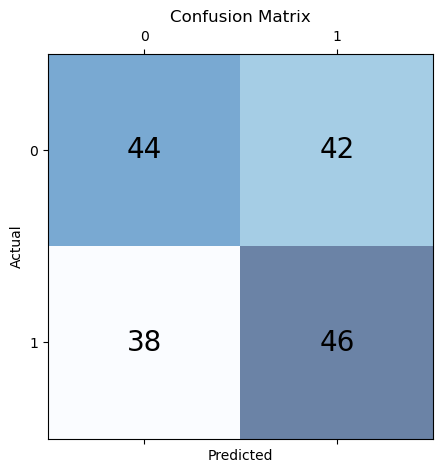

In [25]:
import matplotlib.pyplot as plt

# Function to compute confusion matrix
def confusion_matrix(y_true, y_pred):
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    return [[tn, fp], [fn, tp]]

# Use the simple rule-based model from previous step
Y_valid_pred = [1 if x[0] > 0 else 0 for x in X_valid]  # x[0] = 'open-close'
cm = confusion_matrix(Y_valid, Y_valid_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5,5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.6)
for i in range(2):
    for j in range(2):
        ax.text(x=j, y=i, s=cm[i][j], va='center', ha='center', fontsize=20)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
